# Aufgabe 2a

Bei dieser Aufgabe sollten, die Frequenzspektren bei der Hochpunktschaltung mit verschiedenen Kopplungskapazitäten gemessen werden. Aus den gemessenen Resonanzfrequenzen $f_1$ und $f_2$ wird der Kopplungsgrad bestimmt und die Kopplungskapazität $C$ durch Anpassung an die theoretische Funktion ermittelt. Der Versuchs aufbau war folgender:

![Hochpunkt-Schaltung kapazitiv gekoppelter Schwingkreise, Schaltplan für Aufgabe 2, entnommen aus dem E17 Dokument von zugehörigen Moodelkurs](./Grafiken/Aufgabe2.png)

Die Resonanzfrequenzen ergibt sich aus den zwei Formeln
$$f_1 = \frac{1}{2\pi\sqrt{LC}}$$

$$f_2 = \frac{1}{2\pi\sqrt{L(C+C_K)}}$$

wobei $f_1$ unabhängig von $C_K$ ist und $f_2$ wiederum nicht.

Der Kopplungsgrad wird aus den gemessenen Frequenzen berechnet und gegen die Kopplungskapazität aufgetragen. Durch Anpassung der Funktion $k_C = \frac{C_K}{C+C_K}$ erhalten wir die gesuchte Kapazität $C$.

[]

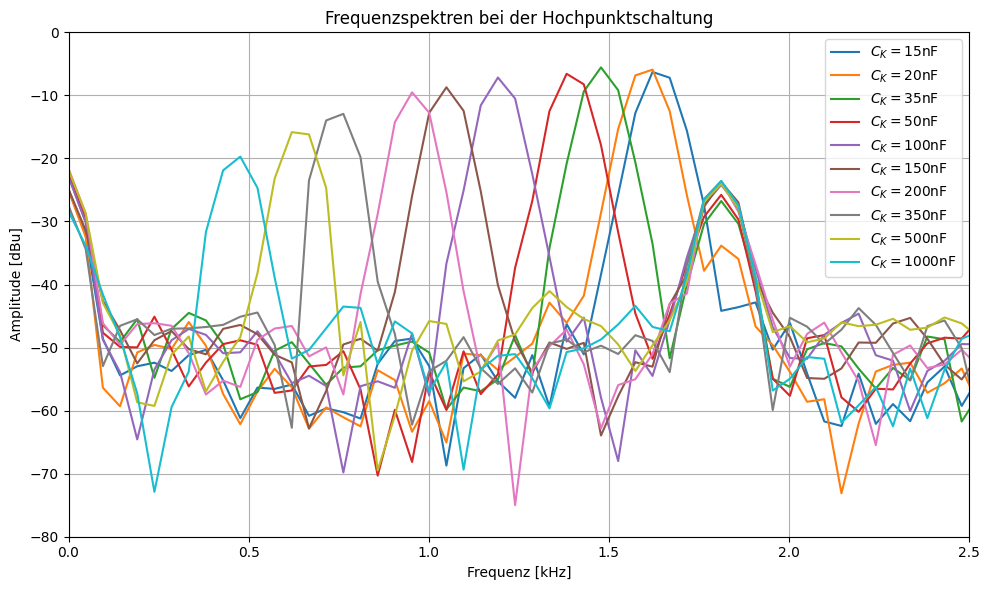

In [46]:
# fig-cap: Frequenzspektren der Hochpunktschaltung, wobei das jeweils rechte Maximum bei $f_0$ liegt für alle Messungen.

import pandas as pd
import matplotlib.pyplot as plt

werte = [[15, 1.84, 1.63],
[20, 1.82, 1.62],
[35, 1.82, 1.48],
[50, 1.82, 1.39],
[100, 1.81, 1.20],
[150, 1.81, 1.05],
[200, 1.81, 0.96],
[350, 1.81, 0.77],
[500, 1.81, 0.64],
[1000, 1.81, 0.48]]

capacity = [[1, 15], [2, 20], [3, 35], [4, 50], [5, 100], [6, 150], [7, 200], [8, 350], [9, 500], [10, 1000]]

plt.figure(figsize=(10, 6))

for i in werte:
    df = pd.read_csv(f"./Messdaten/Aufgabe2/Gegensinnig/E17_Aufgabe2_Kapazitaet_{i[0]}nF.csv")

    plt.plot(df["Frequency[kHz]"], df["Channel[dBu]"], label=f"$C_K = {i[0]}$nF")

plt.xlim(0, 2.5)
plt.ylim(-80, 0)
plt.grid()
plt.title("Frequenzspektren bei der Hochpunktschaltung")
plt.xlabel("Frequenz [kHz]")
plt.ylabel("Amplitude [dBu]")
plt.tight_layout()
plt.legend()
plt.plot()

## Fit des Kopplungsgrad

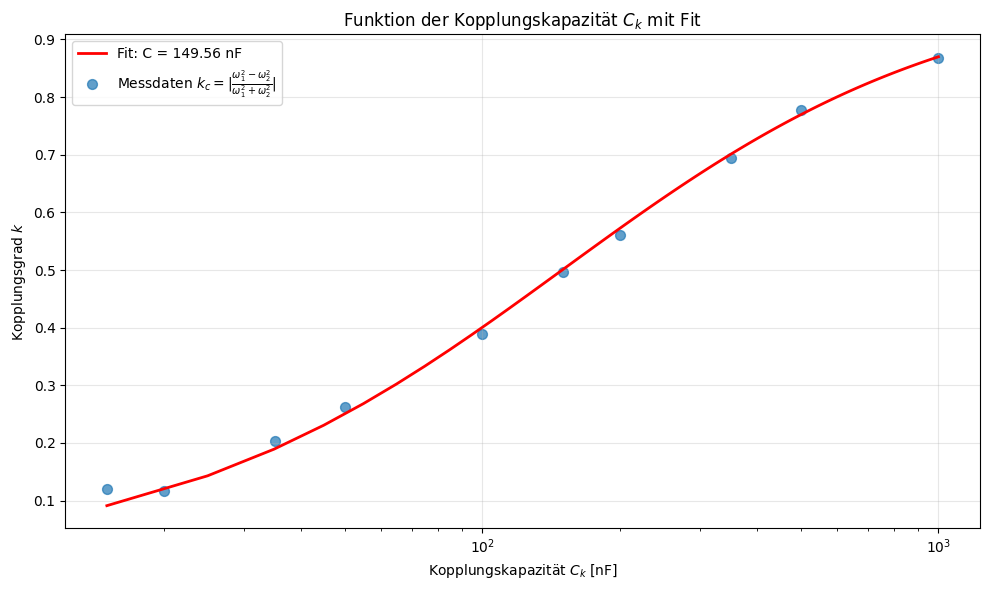

C = 149.560149 nF


In [ ]:
# | fig-cap: Funktion der Kopplungskapazität $C_k$ mit Fit, mit $C \approx 149.6$ nF

from scipy.optimize import curve_fit
import numpy as np

x = []
y = []

for i in werte:
    y.append(i[0])
    omega1 = 2* np.pi * i[1]
    omega2 = 2* np.pi * i[2]
    x.append(np.abs((omega1**2 - omega2**2)/(omega1**2 + omega2**2)))

# Define the fitting function: k = C_k / (C + C_k)
# C_k is the independent variable (x-axis), C is the parameter to fit
def coupling_degree(C_k, C):
    return C_k / (C + C_k)

p0 = [50.0]
bounds = ([1e-9], [np.inf])

popt, pcov = curve_fit(coupling_degree, y, x, p0=p0, bounds=bounds, maxfev=20000)
C_fit = float(popt[0])

# Plot the fit
y_fit = np.linspace(min(y), max(y), 100)
x_fit = coupling_degree(y_fit, C_fit)
plt.figure(figsize=(10, 6))
plt.plot(y_fit, x_fit, 'r-', label=f'Fit: C = {C_fit:.2f} nF', linewidth=2)

plt.scatter(y, x, s=50, alpha=0.7, label='Messdaten $k_c = \\vert \\frac{\\omega_1^2 - \\omega_2^2}{\\omega_1^2 + \\omega_2^2} \\vert$')
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("Kopplungskapazität $C_k$ [nF]")
plt.ylabel("Kopplungsgrad $k$")
plt.title("Funktion der Kopplungskapazität $C_k$ mit Fit")
plt.legend()
plt.tight_layout()
plt.show()

print(f"C = {C_fit:.6f} nF")

Mit $C \approx 149.6$ nF kommen wir auf einen sehr ähnlichen Wert wie in Aufgabe 1, mit $C = 149.4$ nF. Die leichte ABweichung, kann auf Messfehler zurückgeführt werden oder auf Schltkreiskomponenten (Wiederstände oder anderes) mit eigneer Kapazität

# Aufgabe 2b
Indem ein Schalter in der Hochpunktschaltung überbrückt wird, wird die Spannung nur auf einer Seite angelegt. Dadurch können wir bei einer Einstellung von $C_K = 50$ nF die Schwebungsschwingung und das entsprechende Frequenzspektrum aufnehmen.

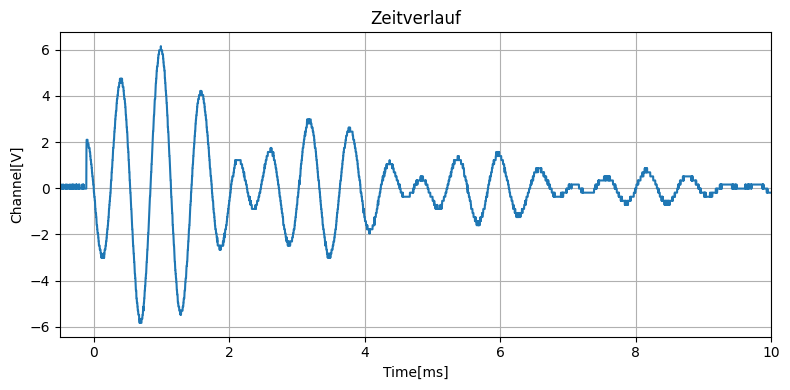

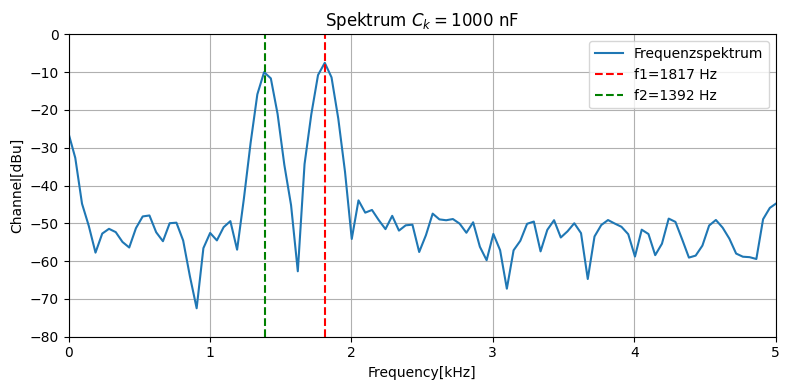

In [25]:
# | fig-cap:
# |     - Schwebungsschwingung bei der Hochpunktschaltung für $C_K = 50$ nF
# |     - Frequenzspektrum, mit zwei ausgeprägten Maxima, der Schwebungsschwingung bei der Hochpunktschaltung für $C_K = 50$ nF

f1 = 1.817e3 #Hz
f2 = 1.392e3 #Hz

spektrum = pd.read_csv(f"./Messdaten/Aufgabe2/Schwebung/E17_Aufgabe2b_Kapazitaet_50nF_Spektrum.csv")
zeit = pd.read_csv(f"./Messdaten/Aufgabe2/Schwebung/E17_Aufgabe2b_Kapazitaet_50nF_Zeit.csv")


# Time signal
plt.figure(figsize=(8,4))
xcol_t, ycol_t = zeit.columns[0], zeit.columns[1]
#plt.subplot(2,1,2)
plt.plot(zeit[xcol_t], zeit[ycol_t])
plt.grid()
plt.xlabel(xcol_t)
plt.ylabel(ycol_t)
plt.title("Zeitverlauf")
plt.xlim(-0.5, 10)
plt.tight_layout()
plt.show()

# plot spectrum and time for current i (uses spektrum and zeit already read)
plt.figure(figsize=(8,4))

# Spectrum
xcol_s, ycol_s = spektrum.columns[0], spektrum.columns[1]
#plt.subplot(2,1,1)
plt.plot(spektrum[xcol_s], spektrum[ycol_s], label="Frequenzspektrum")
# convert marker frequencies to axis units if needed
f1_plot, f2_plot = f1, f2
if 'khz' in xcol_s.lower():
    f1_plot, f2_plot = f1/1e3, f2/1e3
plt.axvline(f1_plot, color='r', linestyle='--', label=f'f1={f1:.0f} Hz')
plt.axvline(f2_plot, color='g', linestyle='--', label=f'f2={f2:.0f} Hz')
plt.legend()
plt.grid()
plt.xlabel(xcol_s)
plt.ylabel(ycol_s)
plt.xlim(0, 5)
plt.ylim(-80, 0)
plt.title(f"Spektrum $C_k={i[0]}$ nF")
plt.tight_layout()
plt.show()



Wir erhalten die Frequenzen $f_1 = 1.871 \pm 0.10$ kHz und $f_2 = 1.392 \pm 0.10$ kHz. Die Periodendauer, erhält man aus einer Frequenz durch $T = \frac{1}{f} = \frac{2\pi}{\omega}$, sodass mit $f_2 = f_0$ und $f_S = f_2 - f_1$ wir die Periodendauer der Schwebung finden:

$$T_S = \frac{1}{f_S} = \frac{1}{f_2 - f_1}$$

Aus den gemessenen Frequenzen erhalten wir die Schwebungsfrequenz:
$$f_S = f_2 - f_1 = 1392 - 1817 = -425 \text{ Hz}$$

Somit beträgt die Schwebungsperiode:
$$T_S = \frac{1}{|f_S|} = \frac{1}{425} \approx 2.35 \text{ ms}$$

Aus der Schwebungsschwingung im Zeitverlauf können wir experimentell $T_S \approx 2.35$ ms bestätigen. Mit einem kurzen Vergleich zu der Aufgabe 2a stimmen die Werte gut zueinander.
